In [1]:
from cellmender.simulation import simulate_cells
from cellmender.simulation import simple_simulation
import cellmender.utils as cm_utils
from cellmender import denoise_count_matrix
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import os

cellmender_dir = os.path.dirname(os.path.abspath(""))
out_dir = os.path.join(cellmender_dir, "notebooks", "output", "debug_sim")

/opt/anaconda3/envs/cellmender/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
data = simple_simulation()
print(data)

AnnData object with n_obs × n_vars = 5000 × 2000
    obs: 'cellid', 'celltype', 'is_empty', 'ambient_fraction'
    var: 'ambient_profile'
    uns: 'simulation_params', 'type_profiles'


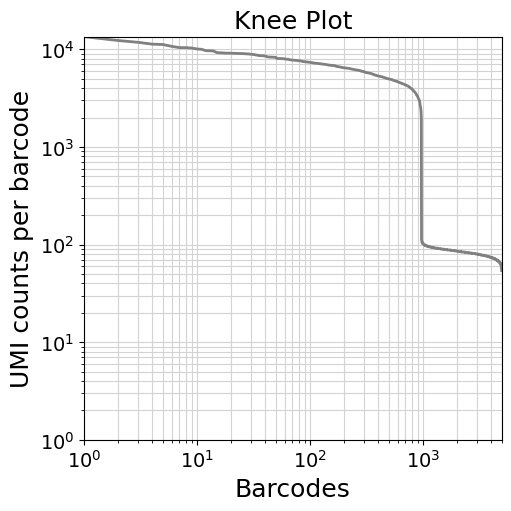

In [3]:
cm_utils.knee_plot(data)

In [5]:
adata_cellmender_path = os.path.join(out_dir, "adata_cellmender.h5ad")
adata_log_path = os.path.join(out_dir, "cellmender.log")
denoised_data = denoise_count_matrix(data, max_iter=150, beta=0.03, cell_ambient_fraction=0.01, verbose=2, log_file = adata_log_path)

16:05:17 - INFO - Inferring gene ambient fractions.
16:05:17 - INFO - Added 'ambient_fraction' to adata.var.
16:05:17 - INFO - Inferring celltype profiles.
16:05:17 - INFO - Number of parameters in the cellmender model: 27,721 (alpha_i: 972, beta: 1, gamma_type: 8,748, p_k: 18,000)
16:05:17 - INFO - adata.obs does not have 'cell_ambient_fraction'. Setting to `cell_ambient_fraction` argument.
16:05:17 - INFO - Performing Sparse EM


Logging to /Users/mcaskey/Desktop/cellmender/notebooks/output/debug_sim/cellmender.log


16:05:18 - INFO - EM Iter   1: ll=-34351285.385 mean_alpha=0.034632 beta=0.011202
16:05:18 - INFO - EM Iter   2: ll=-40028539.885 mean_alpha=0.039086 beta=0.015142
16:05:18 - INFO - EM Iter   3: ll=-39773109.547 mean_alpha=0.039690 beta=0.015726
16:05:19 - INFO - EM Iter   4: ll=-39765750.792 mean_alpha=0.039875 beta=0.015864
16:05:19 - INFO - EM Iter   5: ll=-39764385.162 mean_alpha=0.039978 beta=0.015901
16:05:19 - INFO - EM Iter   6: ll=-39763910.556 mean_alpha=0.040064 beta=0.015908
16:05:20 - INFO - EM Iter   7: ll=-39763633.141 mean_alpha=0.040152 beta=0.015905
16:05:20 - INFO - EM Iter   8: ll=-39763405.111 mean_alpha=0.040246 beta=0.015897
16:05:20 - INFO - EM Iter   9: ll=-39763191.462 mean_alpha=0.040348 beta=0.015887
16:05:21 - INFO - EM Iter  10: ll=-39762983.628 mean_alpha=0.040459 beta=0.015876
16:05:21 - INFO - EM Iter  11: ll=-39762779.541 mean_alpha=0.040579 beta=0.015865
16:05:21 - INFO - EM Iter  12: ll=-39762578.780 mean_alpha=0.040708 beta=0.015853
16:05:22 - INFO 

/opt/anaconda3/envs/cellmender/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


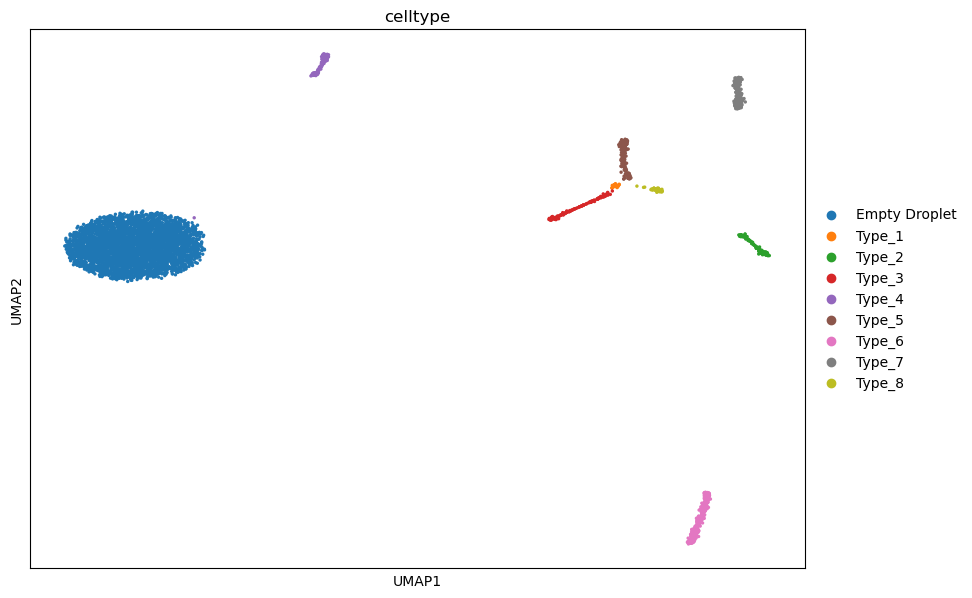

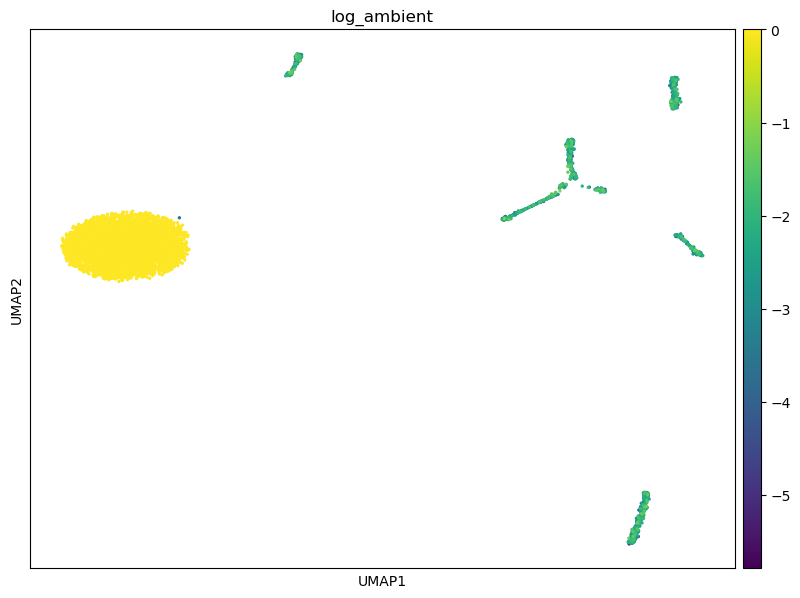

In [ ]:
sc.pp.pca(data, n_comps=30)
sc.pp.neighbors(data, n_neighbors=30, n_pcs=30, knn=True)
sc.tl.umap(data)
fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='celltype', ax=ax)
fig, ax = plt.subplots(figsize=(10, 7))
data.obs['log_ambient'] = np.log(data.obs['ambient_fraction'])
sc.pl.umap(data, color='log_ambient', ax=ax)

In [ ]:
real_mask = ~denoised_data.obs["is_empty"]
print(denoised_data.obs[real_mask])

           cellid celltype  is_empty  ambient_fraction  cell_ambient_fraction  \
cell_2          5   Type_5     False          0.007032                   0.01   
cell_3          6   Type_6     False          0.094343                   0.01   
cell_5          5   Type_5     False          0.041950                   0.01   
cell_19         7   Type_7     False          0.128143                   0.01   
cell_20         6   Type_6     False          0.099207                   0.01   
...           ...      ...       ...               ...                    ...   
cell_4969       2   Type_2     False          0.061252                   0.01   
cell_4974       3   Type_3     False          0.170702                   0.01   
cell_4991       2   Type_2     False          0.065687                   0.01   
cell_4992       4   Type_4     False          0.037516                   0.01   
cell_4997       5   Type_5     False          0.125038                   0.01   

           alpha_hat  z_hat

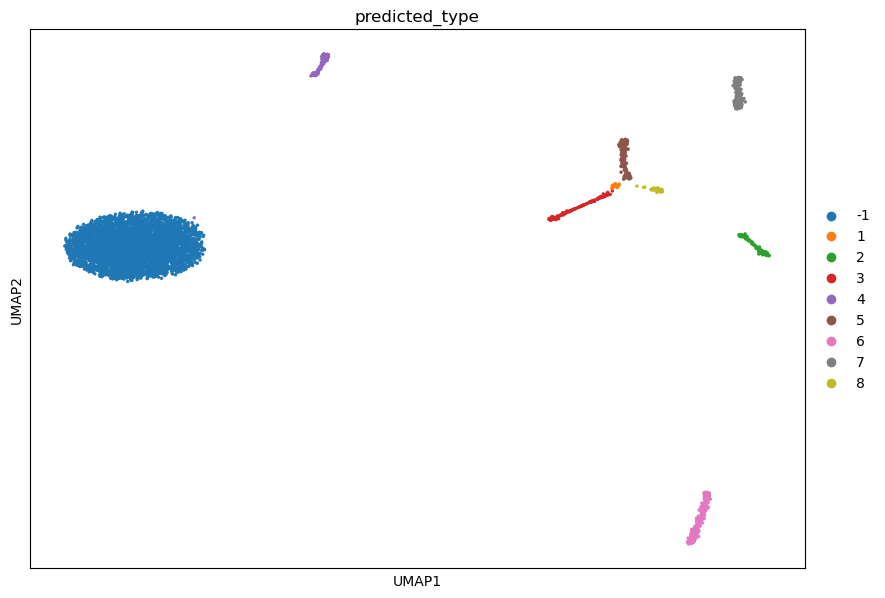

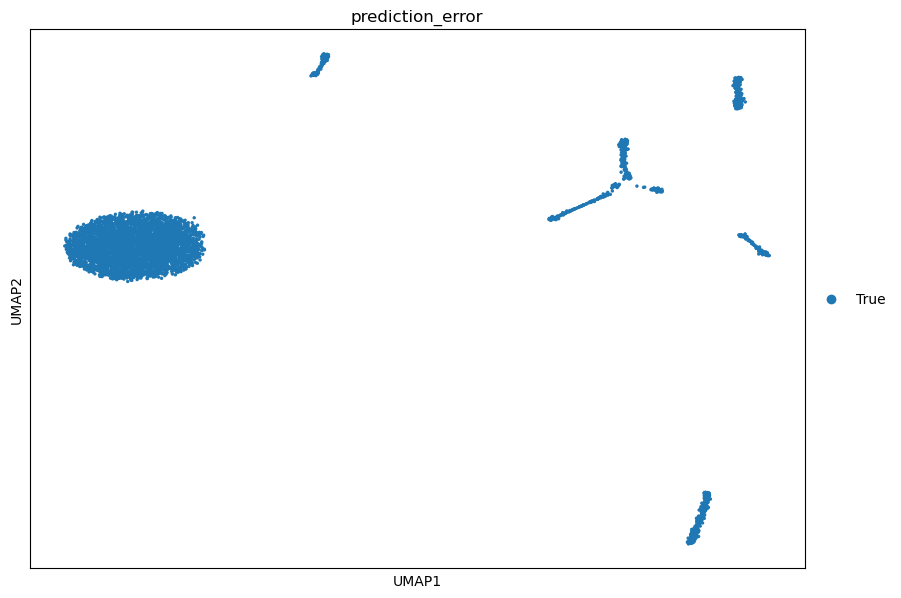

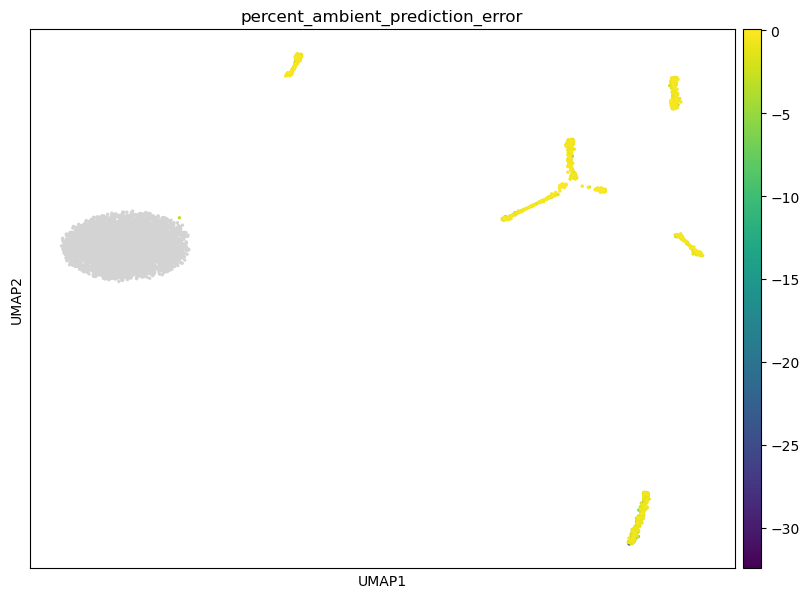

In [ ]:
data.obs['percent_ambient_prediction_error'] = (data.obs['ambient_fraction'] - denoised_data.obs['alpha_hat'])/data.obs['ambient_fraction']
data.obs['percent_ambient_prediction_error'] = data.obs['percent_ambient_prediction_error'].mask(~real_mask, np.nan)
data.obs['predicted_type'] = denoised_data.obs['z_hat'].astype('category')
data.obs['prediction_error'] = (denoised_data.obs['z_hat'] == denoised_data.obs['cellid'])

fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='predicted_type', ax=ax)
fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='prediction_error',ax=ax)
fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='percent_ambient_prediction_error', ax=ax)